# E-Commerce Customer Churn Prediction Using Machine Learning

## Complete Project Workflow

**Data Understanding → Data Cleaning → EDA → Feature Preparation → Train-Test Split → Machine Learning → Prediction → Evaluation → New Customer Prediction → Findings → Conclusion**


# 1. Data Understanding

## 1.1 Import Required Libraries

In [1]:
# 1.1 Import Required Libraries

import pandas as pd
import numpy as np


## 1.2 Load the Raw E-Commerce Dataset

In [2]:
# 1.2 Load Raw Dataset

df = pd.read_csv("ecommerce_customer_churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (50000, 25)


## 1.3 View First 5 Rows

In [3]:
# 1.3 View First 5 Rows

print(df.head())


    Age  Gender Country        City  Membership_Years  Login_Frequency  \
0  43.0    Male  France   Marseille               2.9             14.0   
1  36.0    Male      UK  Manchester               1.6             15.0   
2  45.0  Female  Canada   Vancouver               2.9             10.0   
3  56.0  Female     USA    New York               2.6             10.0   
4  35.0    Male   India       Delhi               3.1             29.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  27.4                6.0                   50.6   
1                  42.7               10.3                   37.7   
2                  24.8                1.6                   70.9   
3                  38.4               14.8                   41.7   
4                  51.4                NaN                   19.1   

   Wishlist_Items  ...  Email_Open_Rate  Customer_Service_Calls  \
0             3.0  ...             17.9                     9.0   
1     

## 1.4 Check Dataset Shape

In [4]:
# 1.4 Check Dataset Shape

print(df.shape)


(50000, 25)


## 1.5 Check Column Names

In [5]:
# 1.5 Check Column Names

print(df.columns)


Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='str')


## 1.6 Check Dataset Information

In [6]:
# 1.6 Check Dataset Information

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

## 1.7 Descriptive Statistics

In [7]:
# 1.7 Descriptive Statistics

print(df.describe())


                Age  Membership_Years  Login_Frequency  Session_Duration_Avg  \
count  47505.000000      50000.000000     50000.000000          46601.000000   
mean      37.802968          2.984009        11.624660             27.660754   
std       11.834668          2.059105         7.810657             10.871013   
min        5.000000          0.100000         0.000000              1.000000   
25%       29.000000          1.400000         6.000000             19.700000   
50%       38.000000          2.500000        11.000000             26.800000   
75%       46.000000          4.000000        17.000000             34.700000   
max      200.000000         10.000000        46.000000             75.600000   

       Pages_Per_Session  Cart_Abandonment_Rate  Wishlist_Items  \
count       47000.000000           50000.000000    46000.000000   
mean            8.737811              57.079973        4.298391   
std             3.778220              16.282723        3.189754   
min        

# 2. Data Cleaning

**Data Cleaning completed here will not be changed later in the project.**

In [8]:
# 1. Load Dataset
import pandas as pd
import numpy as np

df = pd.read_csv('ecommerce_customer_churn.csv')
clean_data = df.copy()
print(clean_data.shape)


(50000, 25)


In [9]:
# 2. Remove Duplicate Rows
clean_data = clean_data.drop_duplicates()
print('Shape after removing duplicates:', clean_data.shape)


Shape after removing duplicates: (50000, 25)


In [10]:
# 3. Check Missing Values
print(clean_data.isnull().sum())


Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64


In [11]:
# 4. Convert Numerical Columns to Numeric
numeric_columns = [
    'Age', 'Membership_Years', 'Login_Frequency',
    'Session_Duration_Avg', 'Pages_Per_Session',
    'Cart_Abandonment_Rate', 'Wishlist_Items',
    'Total_Purchases', 'Average_Order_Value',
    'Days_Since_Last_Purchase', 'Discount_Usage_Rate',
    'Returns_Rate', 'Email_Open_Rate',
    'Customer_Service_Calls', 'Product_Reviews_Written',
    'Social_Media_Engagement_Score', 'Mobile_App_Usage',
    'Payment_Method_Diversity', 'Lifetime_Value',
    'Credit_Balance'
]

for col in numeric_columns:
    clean_data[col] = pd.to_numeric(clean_data[col], errors='coerce')

print('Numerical columns converted successfully.')


Numerical columns converted successfully.


In [12]:
# 5. Fill Missing Numerical Values
for col in numeric_columns:
    clean_data[col] = clean_data[col].fillna(clean_data[col].mean())

print('Numerical missing values filled.')


Numerical missing values filled.


In [13]:
# 6. Fill Missing Categorical Values
categorical_columns = ['Gender', 'Country', 'City', 'Signup_Quarter']

for col in categorical_columns:
    clean_data[col] = clean_data[col].fillna(clean_data[col].mode()[0])

print('Categorical missing values filled.')


Categorical missing values filled.


In [14]:
# 7. Check Missing Values After Cleaning
print(clean_data.isnull().sum())
print('\nTotal missing values:', clean_data.isnull().sum().sum())


Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

Total missing values: 0


In [15]:
print(clean_data.isnull().sum().sum())

0


In [16]:
# 8. Save Cleaned Dataset
clean_data.to_csv('ecommerce_customer_churn_cleaned.csv', index=False)
print('Cleaned dataset saved successfully!')


Cleaned dataset saved successfully!


# 3. Exploratory Data Analysis (EDA)

## 3.1 Import EDA Libraries

In [17]:
# 3.1 Import EDA Libraries

import matplotlib.pyplot as plt
import seaborn as sns


## 3.2 Customer Churn Distribution

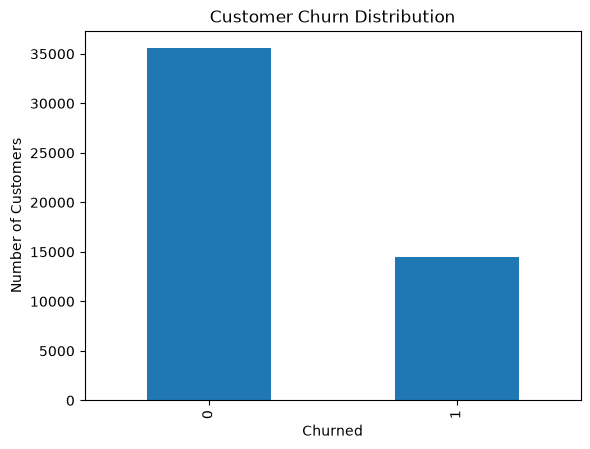

In [18]:
# 3.2 Customer Churn Distribution

clean_data["Churned"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")
plt.show()


## 3.3 Customer Age Distribution

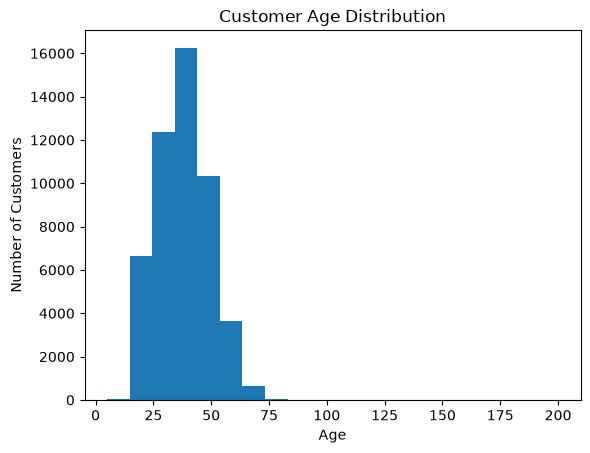

In [19]:
# 3.3 Customer Age Distribution

clean_data["Age"].plot(kind="hist", bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()


## 3.4 Gender Distribution

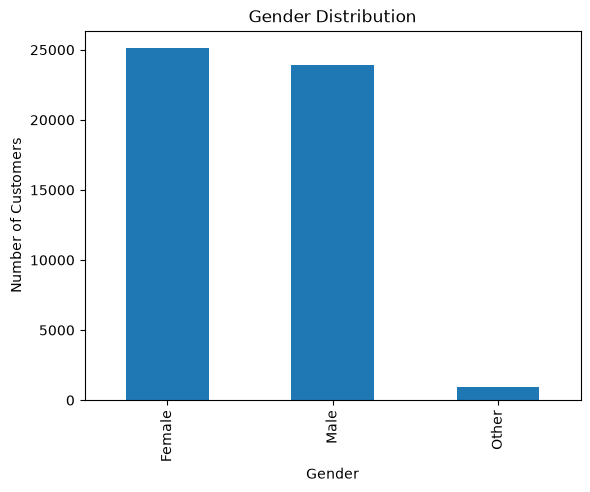

In [20]:
# 3.4 Gender Distribution

clean_data["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


## 3.5 Churn by Gender

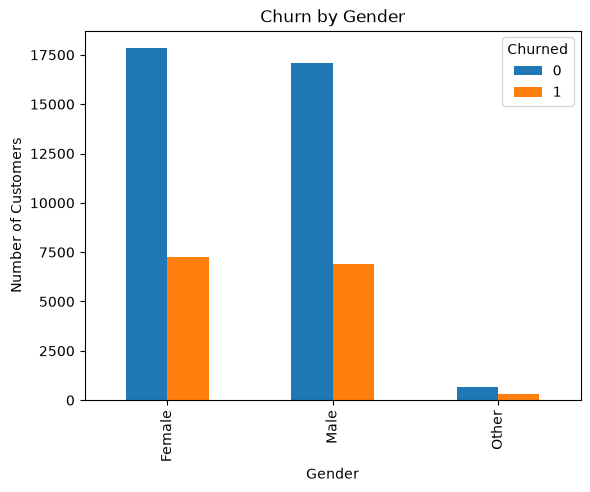

In [21]:
# 3.5 Churn by Gender

pd.crosstab(clean_data["Gender"], clean_data["Churned"]).plot(kind="bar")

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


## 3.6 Churn by Country

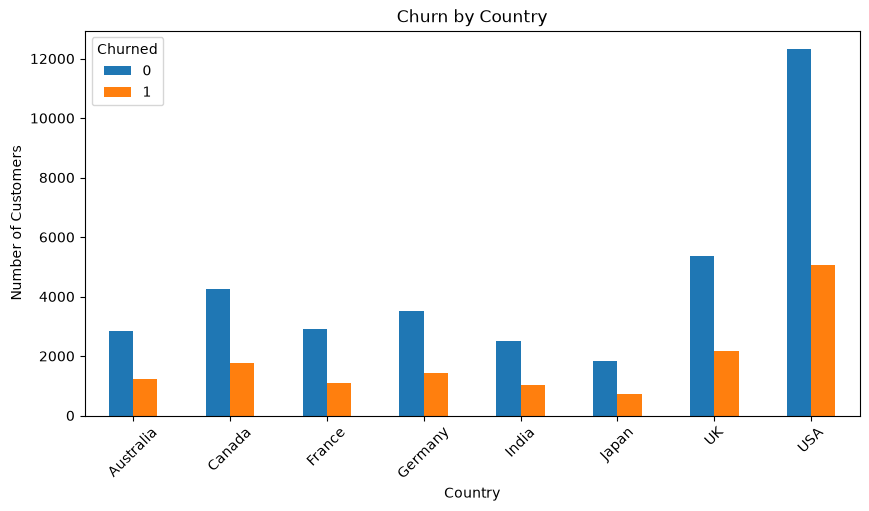

In [22]:
# 3.6 Churn by Country

pd.crosstab(clean_data["Country"], clean_data["Churned"]).plot(kind="bar", figsize=(10, 5))

plt.title("Churn by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()


## 3.7 Correlation Heatmap

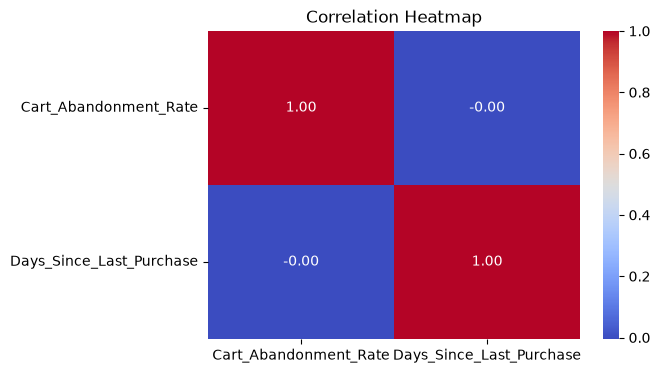

In [23]:
## Correlation Analysis - Cart Abandonment Rate vs Days Since Last Purchase
important_cols = [
    "Cart_Abandonment_Rate",
    "Days_Since_Last_Purchase"
]

plt.figure(figsize=(6, 4))

sns.heatmap(
    clean_data[important_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
numeric_data = clean_data.select_dtypes(include=["number"])

## 3.8 Correlation with Churned

In [26]:
# 3.8 Correlation with Churned

correlation_with_churn = numeric_data.corr()["Churned"].sort_values(ascending=False)
print(correlation_with_churn)


Churned                          1.000000
Customer_Service_Calls           0.290545
Cart_Abandonment_Rate            0.277963
Days_Since_Last_Purchase         0.148633
Returns_Rate                     0.051647
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004412
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.074523
Age                             -0.100444
Credit_Balance                  -0.147935
Total_Purchases                 -0.160029
Product_Reviews_Written         -0.174614
Social_Media_Engagement_Score   -0.179719
Wishlist_Items                  -0.189627
Login_Frequency                 -0.204379
Mobile_App_Usage                -0.211477
Email_Open_Rate                 -0.215104
Session_Duration_Avg            -0.218055
Pages_Per_Session               -0.224880
Name: Churned, dtype: float64


## 3.9 Lifetime Value by Churn Status

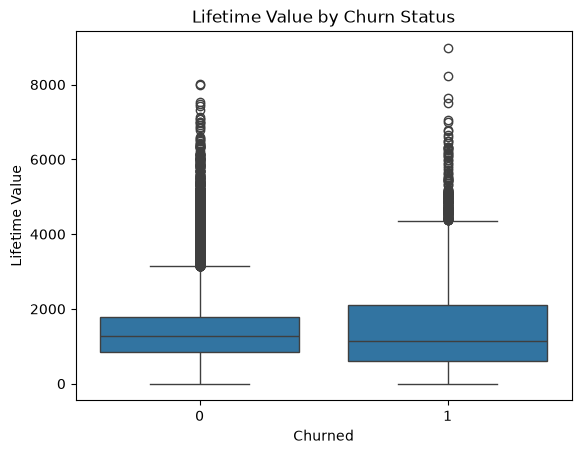

In [ ]:
# 3.9 Lifetime Value by Churn Status

sns.boxplot(data=clean_data, x="Churned", y="Lifetime_Value")

plt.title("Lifetime Value by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Lifetime Value")
plt.show()


## 3.10 Customer Service Calls by Churn Status

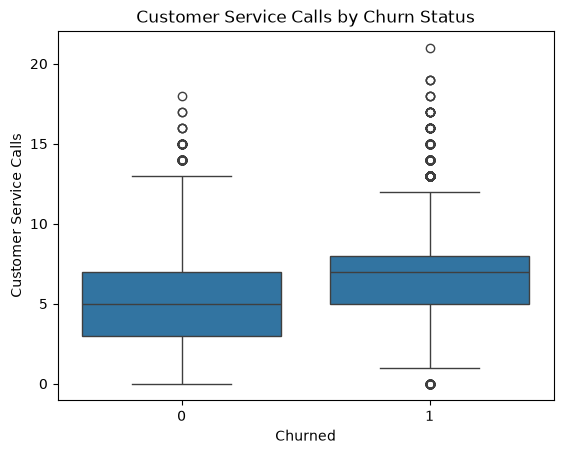

In [ ]:
# 3.10 Customer Service Calls by Churn Status

sns.boxplot(data=clean_data, x="Churned", y="Customer_Service_Calls")

plt.title("Customer Service Calls by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Customer Service Calls")
plt.show()


## 3.11 Statistical Analysis - T-Test

In [ ]:
# 3.11 Statistical Analysis - T-Test

from scipy import stats

churned = clean_data[clean_data["Churned"] == 1]["Lifetime_Value"]
not_churned = clean_data[clean_data["Churned"] == 0]["Lifetime_Value"]

t_stat, p_value = stats.ttest_ind(churned, not_churned, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)


T-Statistic: -2.2221977749804154
P-Value: 0.026279558539959214


## 3.12 Statistical Analysis - Chi-Square Test

In [ ]:
# 3.12 Statistical Analysis - Chi-Square Test

from scipy.stats import chi2_contingency

table = pd.crosstab(clean_data["Gender"], clean_data["Churned"])
chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p_value)
print(dof)


Chi-Square Statistic: 2.963880050963615
P-Value: 0.22719649357069535
2


# 4. Machine Learning

## 4.1 Import Machine Learning Libraries

In [27]:
# 4.1 Import Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 4.2 Define Features and Target

In [28]:
# 4.2 Define Features and Target

X = clean_data.drop("Churned", axis=1)
y = clean_data["Churned"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (50000, 24)
y shape: (50000,)


## 4.3 Encode Categorical Features

In [29]:
# 4.3 Encode Categorical Features

X = pd.get_dummies(X, columns=["Gender", "Country", "City", "Signup_Quarter"], drop_first=False)

print("Encoded X shape:", X.shape)


Encoded X shape: (50000, 75)


## 4.4 Train-Test Split

In [30]:
# 4.4 Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (40000, 75)
X_test shape: (10000, 75)
y_train shape: (40000,)
y_test shape: (10000,)


## 4.5 Feature Scaling for Logistic Regression

In [31]:
# 4.5 Feature Scaling for Logistic Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)


Scaled X_train shape: (40000, 75)
Scaled X_test shape: (10000, 75)


## 4.6 Logistic Regression

In [34]:
# 4.6.1 Logistic Regression - Model Training

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [35]:
# 4.6.2 Logistic Regression - Prediction

y_pred_lr = logistic_model.predict(X_test_scaled)

print("Logistic Regression Predictions:")
print(y_pred_lr[:20])


Logistic Regression Predictions:
[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


In [36]:
# 4.6.3 Logistic Regression - Evaluation

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print("Logistic Regression Accuracy Percentage:", accuracy_lr * 100)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.775
Logistic Regression Accuracy Percentage: 77.5

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      7110
           1       0.68      0.42      0.52      2890

    accuracy                           0.78     10000
   macro avg       0.74      0.67      0.69     10000
weighted avg       0.76      0.78      0.76     10000


Confusion Matrix:
[[6524  586]
 [1664 1226]]


## 4.7 Decision Tree Classifier

In [37]:
# 4.7.1 Decision Tree Classifier - Model Training

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")


Decision Tree model trained successfully.


In [39]:
# 4.7.2 Decision Tree Classifier - Prediction

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Predictions:")
print(y_pred_dt[:20])


Decision Tree Predictions:
[0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0]


In [40]:
# 4.7.3 Decision Tree Classifier - Evaluation

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Decision Tree Accuracy Percentage:", accuracy_dt * 100)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8866
Decision Tree Accuracy Percentage: 88.66000000000001

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7110
           1       0.86      0.72      0.79      2890

    accuracy                           0.89     10000
   macro avg       0.88      0.84      0.85     10000
weighted avg       0.89      0.89      0.88     10000


Confusion Matrix:
[[6771  339]
 [ 795 2095]]


## 4.8 Random Forest Classifier

In [41]:
# 4.8.1 Random Forest Classifier - Model Training

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [42]:
# 4.8.2 Random Forest Classifier - Prediction

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(y_pred_rf[:20])


Random Forest Predictions:
[0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0]


In [44]:
# 4.8.3 Random Forest Classifier - Evaluation

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest Accuracy Percentage:", accuracy_rf * 100)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.911
Random Forest Accuracy Percentage: 91.10000000000001

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7110
           1       0.92      0.76      0.83      2890

    accuracy                           0.91     10000
   macro avg       0.91      0.87      0.89     10000
weighted avg       0.91      0.91      0.91     10000


Confusion Matrix:
[[6908  202]
 [ 688 2202]]


## 4.9 Gradient Boosting Classifier

In [43]:
# 4.9.1 Gradient Boosting Classifier - Model Training

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")


Gradient Boosting model trained successfully.


In [45]:
# 4.9.2 Gradient Boosting Classifier - Prediction

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Predictions:")
print(y_pred_gb[:20])


Gradient Boosting Predictions:
[0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]


In [46]:
# 4.9.3 Gradient Boosting Classifier - Evaluation

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)
print("Gradient Boosting Accuracy Percentage:", accuracy_gb * 100)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.9191
Gradient Boosting Accuracy Percentage: 91.91

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7110
           1       0.94      0.77      0.85      2890

    accuracy                           0.92     10000
   macro avg       0.93      0.88      0.90     10000
weighted avg       0.92      0.92      0.92     10000


Confusion Matrix:
[[6960  150]
 [ 659 2231]]


## 4.10 Model Accuracy Comparison

In [47]:
# 4.10 Model Accuracy Comparison

model_accuracy = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Accuracy": [accuracy_lr, accuracy_dt, accuracy_rf, accuracy_gb]
})

model_accuracy["Accuracy Percentage"] = model_accuracy["Accuracy"] * 100
print(model_accuracy)


                 Model  Accuracy  Accuracy Percentage
0  Logistic Regression    0.7750                77.50
1        Decision Tree    0.8866                88.66
2        Random Forest    0.9110                91.10
3    Gradient Boosting    0.9191                91.91


## 4.11 Select the Best Model

In [52]:
# 4.11 Select the Best Model

model_dict = {
    "Logistic Regression": (logistic_model, accuracy_lr),
    "Decision Tree": (dt_model, accuracy_dt),
    "Random Forest": (rf_model, accuracy_rf),
    "Gradient Boosting": (gb_model, accuracy_gb)
}

best_model_name = max(model_dict, key=lambda name: model_dict[name][1])
best_model = model_dict[best_model_name][0]
best_accuracy = model_dict[best_model_name][1]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy * 100)


Best Model: Gradient Boosting
Best Accuracy: 91.91


# 6. Findings

## 6.1 Final Findings

In [ ]:
# 6.1 Final Findings

print("FINAL FINDINGS")
print("------------------------------")
print("Total Customers:", len(clean_data))
print("Not Churned Customers:", (clean_data["Churned"] == 0).sum())
print("Churned Customers:", (clean_data["Churned"] == 1).sum())
print("\nBest Model:", best_model_name)
print("Best Accuracy:", f"{best_accuracy * 100:.2f}%")
print("\nNew Customer Prediction:")
if new_prediction[0] == 1:
    print("The new customer is predicted to Churn.")
else:
    print("The new customer is predicted to Not Churn.")


FINAL FINDINGS
------------------------------
Total Customers: 50000
Not Churned Customers: 35550
Churned Customers: 14450

Best Model: Gradient Boosting
Best Accuracy: 91.91%

New Customer Prediction:
The new customer is predicted to Not Churn.


## 6.2 Business Insights

- The project uses customer behaviour data to predict whether a customer is likely to churn.
- EDA is used to understand churn distribution and relationships among important customer features.
- Multiple classification models are trained and evaluated on the same test data.
- The best-performing model is selected based on test accuracy.
- The final model can be used to make a churn prediction for a new customer.

# 7. Conclusion

This project demonstrates an end-to-end **E-Commerce Customer Churn Prediction** workflow.

The raw customer dataset was first understood and cleaned. Missing values were handled and the cleaned dataset was saved. EDA was then performed to understand customer churn patterns and relationships among important variables.

For machine learning, categorical features were encoded and the dataset was divided into training and testing sets. Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting classifiers were trained. Each model follows the order **Model Training → Prediction → Evaluation**.

Finally, the best-performing model was used to predict churn for a new customer.

**Project Objective:** Predict customer churn using machine learning and identify customers who may be at risk of leaving an e-commerce business.

# 8. Advanced Machine Learning

The original EDA and basic machine learning sections above are kept unchanged. This section adds advanced models and hyperparameter tuning to improve model performance and strengthen the project for a real-world machine learning workflow.

## 8.1 Advanced ML Libraries

This section prepares the libraries required for hyperparameter tuning, XGBoost and LightGBM.

In [49]:
# 8.1 Advanced ML Libraries

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Install only if the packages are not already available
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])

if importlib.util.find_spec("lightgbm") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm", "-q"])

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Advanced ML libraries loaded successfully.")

Advanced ML libraries loaded successfully.


## 8.2 Hyperparameter Tuning – Random Forest

In [50]:
# 8.2 Hyperparameter Tuning - Random Forest

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=6,
    scoring="accuracy",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
rf_tuned_model = rf_search.best_estimator_

print("Best Random Forest Parameters:")
print(rf_search.best_params_)
print("Best Cross-Validation Accuracy:", rf_search.best_score_)

Best Random Forest Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
Best Cross-Validation Accuracy: 0.9103000373869404


## 8.3 Hyperparameter Tuning – Gradient Boosting

In [51]:
# 8.3 Hyperparameter Tuning - Gradient Boosting

gb_param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=6,
    scoring="accuracy",
    cv=3,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)
gb_tuned_model = gb_search.best_estimator_

print("Best Gradient Boosting Parameters:")
print(gb_search.best_params_)
print("Best Cross-Validation Accuracy:", gb_search.best_score_)

Best Gradient Boosting Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.05}
Best Cross-Validation Accuracy: 0.9191250123985962


## 8.4 Tuned Gradient Boosting – Model Training

In [53]:
# 8.4 Tuned Gradient Boosting - Model Training

gb_tuned_model.fit(X_train, y_train)
print("Tuned Gradient Boosting model trained successfully.")

Tuned Gradient Boosting model trained successfully.


## 8.5 Tuned Gradient Boosting – Prediction

In [54]:
# 8.5 Tuned Gradient Boosting - Prediction

y_pred_gb_tuned = gb_tuned_model.predict(X_test)
print("Tuned Gradient Boosting Predictions:")
print(y_pred_gb_tuned[:20])

Tuned Gradient Boosting Predictions:
[0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]


## 8.6 Tuned Gradient Boosting – Evaluation

In [55]:
# 8.6 Tuned Gradient Boosting - Evaluation

accuracy_gb_tuned = accuracy_score(y_test, y_pred_gb_tuned)
print("Tuned Gradient Boosting Accuracy:", accuracy_gb_tuned)
print("Tuned Gradient Boosting Accuracy Percentage:", accuracy_gb_tuned * 100)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb_tuned))

Tuned Gradient Boosting Accuracy: 0.9215
Tuned Gradient Boosting Accuracy Percentage: 92.15

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7110
           1       0.93      0.79      0.85      2890

    accuracy                           0.92     10000
   macro avg       0.92      0.88      0.90     10000
weighted avg       0.92      0.92      0.92     10000


Confusion Matrix:
[[6940  170]
 [ 615 2275]]


## 8.7 XGBoost – Model Training

In [56]:
# 8.7 XGBoost - Model Training

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## 8.8 XGBoost – Prediction

In [57]:
# 8.8 XGBoost - Prediction

y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Predictions:")
print(y_pred_xgb[:20])

XGBoost Predictions:
[0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]


## 8.9 XGBoost – Evaluation

In [58]:
# 8.9 XGBoost - Evaluation

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)
print("XGBoost Accuracy Percentage:", accuracy_xgb * 100)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.924
XGBoost Accuracy Percentage: 92.4

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7110
           1       0.93      0.80      0.86      2890

    accuracy                           0.92     10000
   macro avg       0.93      0.89      0.90     10000
weighted avg       0.92      0.92      0.92     10000


Confusion Matrix:
[[6934  176]
 [ 584 2306]]


## 8.10 LightGBM – Model Training

In [59]:
# 8.10 LightGBM - Model Training

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)
print("LightGBM model trained successfully.")

LightGBM model trained successfully.


## 8.11 LightGBM – Prediction

In [60]:
# 8.11 LightGBM - Prediction

y_pred_lgbm = lgbm_model.predict(X_test)
print("LightGBM Predictions:")
print(y_pred_lgbm[:20])

LightGBM Predictions:
[0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0]


## 8.12 LightGBM – Evaluation

In [61]:
# 8.12 LightGBM - Evaluation

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
print("LightGBM Accuracy:", accuracy_lgbm)
print("LightGBM Accuracy Percentage:", accuracy_lgbm * 100)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

LightGBM Accuracy: 0.9225
LightGBM Accuracy Percentage: 92.25

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7110
           1       0.92      0.80      0.86      2890

    accuracy                           0.92     10000
   macro avg       0.92      0.89      0.90     10000
weighted avg       0.92      0.92      0.92     10000


Confusion Matrix:
[[6919  191]
 [ 584 2306]]


## 8.13 Advanced Model Accuracy Comparison

In [62]:
# 8.13 Advanced Model Accuracy Comparison

advanced_model_accuracy = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        accuracy_lr, accuracy_dt, accuracy_rf, accuracy_gb,
        accuracy_gb_tuned, accuracy_xgb, accuracy_lgbm
    ]
})

advanced_model_accuracy["Accuracy Percentage"] = advanced_model_accuracy["Accuracy"] * 100
advanced_model_accuracy = advanced_model_accuracy.sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(advanced_model_accuracy)

                     Model  Accuracy  Accuracy Percentage
0                  XGBoost    0.9240                92.40
1                 LightGBM    0.9225                92.25
2  Tuned Gradient Boosting    0.9215                92.15
3        Gradient Boosting    0.9191                91.91
4            Random Forest    0.9110                91.10
5            Decision Tree    0.8866                88.66
6      Logistic Regression    0.7750                77.50


## 8.14 Select Final Advanced Model

In [63]:
# 8.14 Select Final Advanced Model

advanced_model_dict = {
    "Logistic Regression": (logistic_model, accuracy_lr),
    "Decision Tree": (dt_model, accuracy_dt),
    "Random Forest": (rf_model, accuracy_rf),
    "Gradient Boosting": (gb_model, accuracy_gb),
    "Tuned Gradient Boosting": (gb_tuned_model, accuracy_gb_tuned),
    "XGBoost": (xgb_model, accuracy_xgb),
    "LightGBM": (lgbm_model, accuracy_lgbm)
}

final_model_name = max(advanced_model_dict, key=lambda name: advanced_model_dict[name][1])
final_model = advanced_model_dict[final_model_name][0]
final_accuracy = advanced_model_dict[final_model_name][1]

print("Final Selected Model:", final_model_name)
print("Final Model Accuracy:", final_accuracy * 100)

Final Selected Model: XGBoost
Final Model Accuracy: 92.4


In [70]:
import joblib

joblib.dump(final_model, "final_churn_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [71]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model columns saved successfully!")

Model columns saved successfully!


## 8.15 Feature Importance – Final Model

In [64]:
# 8.15 Feature Importance - Final Model

if hasattr(final_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": final_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    print("Top 15 Features Influencing Churn Prediction:")
    print(feature_importance.head(15))
else:
    print("Feature importance is not available for the selected model.")

Top 15 Features Influencing Churn Prediction:
                     Feature  Importance
13    Customer_Service_Calls    0.132200
18            Lifetime_Value    0.125282
10       Discount_Usage_Rate    0.115617
7            Total_Purchases    0.071842
5      Cart_Abandonment_Rate    0.065821
0                        Age    0.056441
9   Days_Since_Last_Purchase    0.027262
6             Wishlist_Items    0.026446
12           Email_Open_Rate    0.025693
14   Product_Reviews_Written    0.020803
8        Average_Order_Value    0.019303
3       Session_Duration_Avg    0.017889
4          Pages_Per_Session    0.016186
2            Login_Frequency    0.015629
16          Mobile_App_Usage    0.014116


# 9. Future Analysis and Business Extension

## 9.1 Churn Probability and Risk Segmentation

The final model can be extended from a simple 0/1 prediction to a churn probability. This allows customers to be grouped into project-defined Low, Medium and High risk segments for further business analysis.

In [65]:
# 9.1 Churn Probability and Risk Segmentation

if hasattr(final_model, "predict_proba"):
    churn_probability = final_model.predict_proba(X_test)[:, 1]

    risk_analysis = pd.DataFrame({
        "Actual_Churned": y_test.values,
        "Churn_Probability": churn_probability
    })

    risk_analysis["Risk_Level"] = pd.cut(
        risk_analysis["Churn_Probability"],
        bins=[-0.01, 0.30, 0.60, 1.00],
        labels=["Low Risk", "Medium Risk", "High Risk"]
    )

    print(risk_analysis.head(10))
    print("\nRisk Level Distribution:")
    print(risk_analysis["Risk_Level"].value_counts())
else:
    print("The selected model does not provide churn probabilities.")

   Actual_Churned  Churn_Probability Risk_Level
0               0           0.054303   Low Risk
1               0           0.037306   Low Risk
2               0           0.240638   Low Risk
3               0           0.027926   Low Risk
4               0           0.044994   Low Risk
5               0           0.054949   Low Risk
6               0           0.037436   Low Risk
7               0           0.060127   Low Risk
8               0           0.038434   Low Risk
9               1           0.894023  High Risk

Risk Level Distribution:
Risk_Level
Low Risk       6969
High Risk      2272
Medium Risk     759
Name: count, dtype: int64


## 9.2 Future Project Enhancements

- Create stronger behavioural features such as RFM metrics when transaction-level data is available.
- Add SHAP-based explainability to show why an individual customer receives a high churn probability.
- Build a Power BI dashboard for churn trends, customer segments and important features.
- Save the final model using Joblib/Pickle for reuse.
- Develop a Streamlit or FastAPI application for real-time customer churn prediction.
- Deploy the application on a suitable cloud platform and monitor model performance over time.
- Retrain the model periodically when new customer data becomes available.

# 5. New Customer Prediction

## 5.1 Create New Customer Data

In [66]:
# 5.1 Create New Customer Data

new_customer = pd.DataFrame([{
    "Age": 35, "Gender": "Male", "Country": "India", "City": "Chennai",
    "Membership_Years": 3.0, "Login_Frequency": 15.0, "Session_Duration_Avg": 30.0,
    "Pages_Per_Session": 8.0, "Cart_Abandonment_Rate": 30.0, "Wishlist_Items": 3,
    "Total_Purchases": 10, "Average_Order_Value": 500, "Days_Since_Last_Purchase": 20,
    "Discount_Usage_Rate": 40.0, "Returns_Rate": 5.0, "Email_Open_Rate": 60.0,
    "Customer_Service_Calls": 2, "Product_Reviews_Written": 4,
    "Social_Media_Engagement_Score": 50.0, "Mobile_App_Usage": 70.0,
    "Payment_Method_Diversity": 2, "Lifetime_Value": 5000, "Credit_Balance": 1000,
    "Signup_Quarter": "Q2"
}])

print("New Customer Data:")
print(new_customer)


New Customer Data:
   Age Gender Country     City  Membership_Years  Login_Frequency  \
0   35   Male   India  Chennai               3.0             15.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  30.0                8.0                   30.0   

   Wishlist_Items  ...  Returns_Rate  Email_Open_Rate  Customer_Service_Calls  \
0               3  ...           5.0             60.0                       2   

   Product_Reviews_Written  Social_Media_Engagement_Score  Mobile_App_Usage  \
0                        4                           50.0              70.0   

   Payment_Method_Diversity  Lifetime_Value  Credit_Balance  Signup_Quarter  
0                         2            5000            1000              Q2  

[1 rows x 24 columns]


## 5.2 Encode New Customer Data

In [67]:
# 5.2 Encode New Customer Data

new_customer_encoded = pd.get_dummies(
    new_customer, columns=["Gender", "Country", "City", "Signup_Quarter"], drop_first=False
)

new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)

print("Encoded New Customer Shape:", new_customer_encoded.shape)


Encoded New Customer Shape: (1, 75)


## 5.3 Predict New Customer Churn

In [68]:
# 5.3 Predict New Customer Churn

if best_model_name == "Logistic Regression":
    new_prediction = best_model.predict(scaler.transform(new_customer_encoded))
else:
    new_prediction = best_model.predict(new_customer_encoded)

print("New Customer Prediction:", new_prediction[0])

if new_prediction[0] == 1:
    print("Result: Customer is likely to Churn")
else:
    print("Result: Customer is likely to Not Churn")


New Customer Prediction: 0
Result: Customer is likely to Not Churn


# 10. Final End-to-End Project Summary

In [69]:
# 10. Final End-to-End Project Summary

print("E-COMMERCE CUSTOMER CHURN PREDICTION - FINAL SUMMARY")
print("=" * 55)
print("Dataset Customers:", len(clean_data))
print("Original ML Best Model:", best_model_name)
print("Original ML Accuracy:", round(best_accuracy * 100, 2), "%")
print("Final Advanced Model:", final_model_name)
print("Final Advanced Accuracy:", round(final_accuracy * 100, 2), "%")
print("\nWorkflow:")
print("Data Understanding -> Data Cleaning -> EDA -> Statistical Analysis ->")
print("Feature Encoding -> Train/Test Split -> Scaling -> Basic ML Models ->")
print("Hyperparameter Tuning -> XGBoost -> LightGBM -> Model Comparison ->")
print("Feature Importance -> Churn Probability/Risk Analysis -> New Customer Prediction")

E-COMMERCE CUSTOMER CHURN PREDICTION - FINAL SUMMARY
Dataset Customers: 50000
Original ML Best Model: Gradient Boosting
Original ML Accuracy: 91.91 %
Final Advanced Model: XGBoost
Final Advanced Accuracy: 92.4 %

Workflow:
Data Understanding -> Data Cleaning -> EDA -> Statistical Analysis ->
Feature Encoding -> Train/Test Split -> Scaling -> Basic ML Models ->
Hyperparameter Tuning -> XGBoost -> LightGBM -> Model Comparison ->
Feature Importance -> Churn Probability/Risk Analysis -> New Customer Prediction
